# Task 1 — MCP Neurons for AND and OR

In [3]:
def MCP_Neurons_AND(X1, X2, T):
    """
    This function implements basic AND operations with MCP Neuron for two inputs.
    """
    assert len(X1) == len(X2)

    summed_inputs = []
    state_neuron = []

    # Element-wise addition
    for i in range(len(X1)):
        summed_inputs.append(X1[i] + X2[i])

    # Apply threshold rule
    for s in summed_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result = MCP_Neurons_AND(X1, X2, T)
print(f"Output of AND gate for inputs {X1} and {X2} with threshold {T}: {result}")

Output of AND gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


In [4]:
def MCP_Neurons_OR(X1, X2, T):
    """
    This function implements basic OR operations with MCP Neuron for two inputs.
    """
    assert len(X1) == len(X2)

    summed_inputs = []
    state_neuron = []

    # Element-wise addition
    for i in range(len(X1)):
        summed_inputs.append(X1[i] + X2[i])

    # Apply threshold rule
    for s in summed_inputs:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


# Example usage
X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"Output of OR gate for inputs {X1} and {X2} with threshold {T}: {result_or}")

Output of OR gate for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


**Task 1**
Limitations of MCP neurons:

MCP neurons use only binary inputs and binary outputs.

They do not learn from data; weights are not updated automatically.

They rely on manually chosen thresholds.

They can only model simple linearly separable logic.

A single MCP neuron cannot solve XOR.

They are highly simplified and do not represent real biological neurons accurately.

They are not suitable for complex pattern recognition problems such as images or speech.

Question 2: Can XOR be solved using a single MCP neuron?

Answer:
No, a single MCP neuron cannot solve XOR because XOR is not linearly separable. There is no single threshold rule that correctly separates the XOR outputs for all four input combinations.

# **Task 2**


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Load the dataset
df_0_1 = pd.read_csv("/content/mnist_0_and_1.csv")

# Extract features and labels
X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


Question 1: What does the shape of X represent?

Answer:
The shape of X represents the number of samples and the number of features per sample.
If X.shape = (n_samples, 784), it means there are n_samples images and each image has 784 pixel values (28 × 28).

Question 2: What does the shape of y represent?

Answer:
The shape of y represents the number of labels, one for each image.
If y.shape = (n_samples,), then each sample in X has one corresponding class label in y.

# **Step 2: Visualize first 5 zeros and first 5 ones**

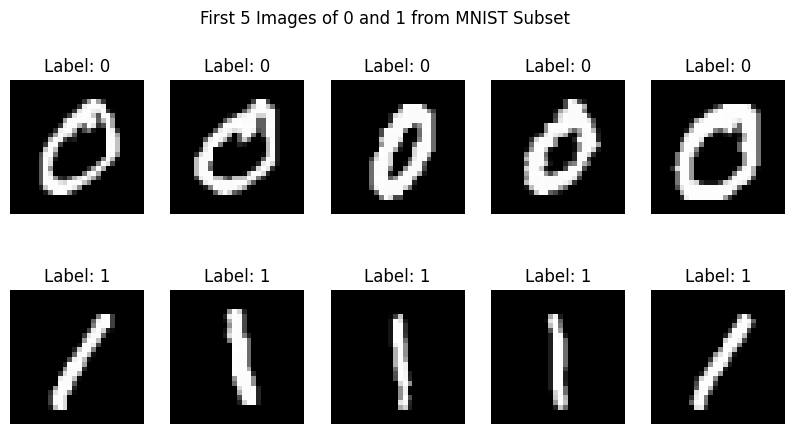

In [10]:
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images in images_0 or images_1 to plot 5 images.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.show()

# **Step 3: Initialize weights and bias**

In [11]:
weights = np.zeros(X.shape[1])   # one weight per pixel
bias = 0
learning_rate = 0.1
epochs = 100

Question 3: What does the weights array represent in this context?

Answer:
The weights array stores the importance of each pixel feature for classification. Since each image has 784 pixels, there are 784 weights. Each weight tells the perceptron how strongly that pixel contributes to predicting whether the digit is 0 or 1.

Question 4: Why are we initializing the weights to zero? What effect could this have on the training process?

Answer:
Weights are initialized to zero for simplicity and because the perceptron learning rule can still update them correctly during training. Starting from zero gives a neutral starting point. The effect is that the model begins with no preference toward either class, then gradually learns from mistakes by updating the weights and bias.

# **Step 4: Decision function**

In [12]:
def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data.
    """
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

# **Step 5: Train perceptron**

In [13]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
    """
    for epoch in range(epochs):
        correct_predictions = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            if y_pred == y[i]:
                correct_predictions += 1
            else:
                # Update weights and bias
                weights = weights + learning_rate * (y[i] - y_pred) * X[i]
                bias = bias + learning_rate * (y[i] - y_pred)

        accuracy = correct_predictions / len(X)

    return weights, bias, accuracy

Question 5: What is the purpose of the line output = np.dot(X[i], weights) + bias?

Answer:
This line computes the weighted sum of the input features plus the bias. It is the perceptron’s raw score for sample i, and it is used to decide whether the prediction should be class 0 or class 1.

Question 6: What happens when the prediction is wrong? How are the weights and bias updated?

Answer:
When the prediction is wrong, the perceptron updates the weights and bias to reduce future errors.

Question 7: Why is the final accuracy important, and what do you expect it to be?

Answer:
Final accuracy tells us how well the perceptron classifies the training data. It is important because it shows whether the model learned a good decision boundary. For digit 0 vs 1, the accuracy is usually expected to be very high, often close to 1.0, because 0 and 1 are relatively easy to separate.

# Step 6: Train the **model**

In [14]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)
print("The Final Accuracy is:", accuracy)

The Final Accuracy is: 1.0


# **Step 7: Evaluate and visualize misclassified images**

In [15]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")

Final Accuracy: 1.0000
All images were correctly classified!


Question 8: What does misclassified_idx store, and how is it used in this code?

Answer:
misclassified_idx stores the indices of samples where the predicted label is different from the true label. It is used to find and display the images that the perceptron classified incorrectly.

Question 9: How do you interpret the result if the output is "All images were correctly classified!"?

Answer:
It means the perceptron made no mistakes on the dataset used for evaluation. In other words, every image was classified correctly, giving an accuracy of 100% on that dataset.

# **3) Task 3 — Perceptron for 3 vs 5 Classification**

In [17]:
# Load dataset
df_3_5 = pd.read_csv("/content/mnist_3_and_5.csv")

# Extract features and labels
X_35 = df_3_5.drop(columns=["label"]).values
y_35 = df_3_5["label"].values

print("Feature matrix shape:", X_35.shape)
print("Label vector shape:", y_35.shape)

Feature matrix shape: (2004, 784)
Label vector shape: (2004,)


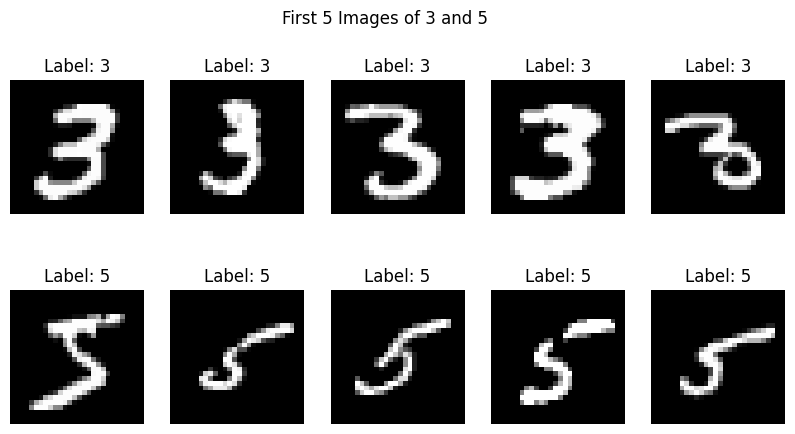

In [18]:
# Visualize first 5 images of 3 and 5
images_3 = X_35[y_35 == 3]
images_5 = X_35[y_35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images to display.")
else:
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5")
plt.show()

In [19]:
# Convert labels to binary: 3 -> 0, 5 -> 1
y_35_binary = np.where(y_35 == 3, 0, 1)

# Initialize weights and bias
weights_35 = np.zeros(X_35.shape[1])
bias_35 = 0
learning_rate = 0.1
epochs = 100

In [20]:
# Train perceptron
weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35_binary, weights_35, bias_35, learning_rate, epochs
)

print("Final Accuracy for 3 vs 5:", accuracy_35)

Final Accuracy for 3 vs 5: 0.9940119760479041


In [21]:
# Predict on all samples
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35 = np.where(predictions_35 >= 0, 1, 0)

final_accuracy_35 = np.mean(y_pred_35 == y_35_binary)
print(f"Final Accuracy: {final_accuracy_35:.4f}")

Final Accuracy: 0.9955


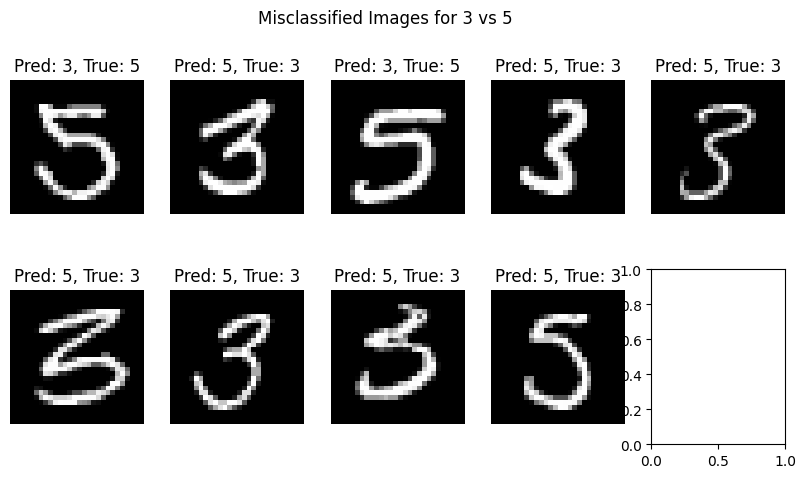

In [22]:
# Misclassified images
misclassified_idx_35 = np.where(y_pred_35 != y_35_binary)[0]

if len(misclassified_idx_35) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx_35[:10]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        pred_label = 5 if y_pred_35[idx] == 1 else 3
        true_label = 5 if y_35_binary[idx] == 1 else 3
        ax.set_title(f"Pred: {pred_label}, True: {true_label}")
        ax.axis("off")

    plt.suptitle("Misclassified Images for 3 vs 5")
    plt.show()
else:
    print("All images were correctly classified!")

# Conclusion for Task 3
Conclusion:
The perceptron works well for simple binary classification, but classifying digits 3 and 5 is harder than classifying 0 and 1 because 3 and 5 have more similar shapes. As a result, the model is likely to make more mistakes on 3 vs 5. This shows a limitation of a single-layer perceptron: it can only learn a linear decision boundary, which may not be enough for more complex image patterns.